In [3]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

CURRENT_DIR = os.getcwd()
file_path = os.path.join(CURRENT_DIR, "Data", "서울시 일별 평균 대기오염도 정보.csv") 

print("현재 작업 디렉토리:", CURRENT_DIR)

if os.path.exists(file_path):
    df = pd.read_csv(file_path, encoding='cp949')
else:
    print(f"🚨 파일을 찾을 수 없습니다! 경로를 확인하세요: {file_path}")
    raise FileNotFoundError(f"파일이 없습니다: {file_path}")

현재 작업 디렉토리: C:\Users\82102\OneDrive\바탕 화면\ai_project\프로젝트


In [4]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# Windows 기본 한글 폰트 지정 (예: 맑은 고딕)
font_path = "C:/Windows/Fonts/malgun.ttf"  # 윈도우 기본 폰트 경로
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 일별 미세먼지/초미세먼지 변화량 시계열 분석 (2025) 

In [5]:
df.head()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
0,20250418,강남구,0.0164,0.0626,0.40,0.0029,68.0,32.0
1,20250418,강남대로,0.0244,0.0405,0.48,0.0022,75.0,34.0
2,20250418,강동구,0.0164,0.0671,0.62,0.0028,77.0,39.0
3,20250418,강변북로,0.0417,0.0367,0.59,0.0028,81.0,28.0
4,20250418,강북구,0.0102,0.0699,0.33,0.0023,56.0,31.0


In [6]:
df["측정일시"].unique()

array([20250418, 20250417, 20250416, 20250415, 20250414, 20250413,
       20250412, 20250411, 20250410, 20250409, 20250408, 20250407,
       20250406, 20250405, 20250404, 20250403, 20250402, 20250401,
       20250331, 20250330, 20250329, 20250328, 20250327, 20250326,
       20250325, 20250324, 20250323, 20250322, 20250321, 20250320,
       20250319, 20250318, 20250317, 20250316, 20250315, 20250314,
       20250313, 20250312, 20250311, 20250310, 20250309, 20250308,
       20250307, 20250306, 20250305, 20250304, 20250303, 20250302,
       20250301, 20250228, 20250227, 20250226, 20250225, 20250224,
       20250223, 20250222, 20250221, 20250220, 20250219, 20250218,
       20250217, 20250216, 20250215, 20250214, 20250213, 20250212,
       20250211, 20250210, 20250209, 20250208, 20250207, 20250206,
       20250205, 20250204, 20250203, 20250202, 20250201, 20250131,
       20250130, 20250129, 20250128, 20250127, 20250126, 20250125,
       20250124, 20250123, 20250122, 20250121, 20250120, 20250

- 2024.4월부터 2025.4월까지 데이터 존재

In [7]:
df.columns

Index(['측정일시', '측정소명', '이산화질소농도(ppm)', '오존농도(ppm)', '일산화탄소농도(ppm)',
       '아황산가스(ppm)', '미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)'],
      dtype='object')

In [8]:
df_2025 = df[df["측정일시"]>=20250101]

In [9]:
df_2025

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
0,20250418,강남구,0.0164,0.0626,0.40,0.0029,68.0,32.0
1,20250418,강남대로,0.0244,0.0405,0.48,0.0022,75.0,34.0
2,20250418,강동구,0.0164,0.0671,0.62,0.0028,77.0,39.0
3,20250418,강변북로,0.0417,0.0367,0.59,0.0028,81.0,28.0
4,20250418,강북구,0.0102,0.0699,0.33,0.0023,56.0,31.0
...,...,...,...,...,...,...,...,...
5395,20250101,한강대로,0.0305,0.0168,0.55,0.0031,42.0,22.0
5396,20250101,항동,0.0207,0.0230,0.67,0.0039,36.0,21.0
5397,20250101,행주,0.0230,0.0233,0.48,0.0036,37.0,16.0
5398,20250101,홍릉로,0.0331,0.0151,0.67,0.0032,38.0,20.0


In [10]:
# 날짜 바꾸기
df_2025["측정일시"] = pd.to_datetime(df_2025["측정일시"], format="%Y%m%d")

# 서울시 전체의  날짜별 미세먼지, 초미세먼지 평균 계산 
seoul_df = df_2025.groupby("측정일시")[['미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)']].mean()

C:\Users\82102\AppData\Local\Temp\ipykernel_3552\3626547141.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025["측정일시"] = pd.to_datetime(df_2025["측정일시"], format="%Y%m%d")


In [11]:
seoul_df

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
측정일시,,
2025-01-01,41.04,20.32
2025-01-02,35.58,18.44
2025-01-03,23.96,13.12
2025-01-04,31.32,18.70
2025-01-05,33.46,24.44
...,...,...
2025-04-14,16.90,8.88
2025-04-15,24.34,14.22
2025-04-16,42.26,23.74


In [12]:
seoul_df.to_csv('서울특별시_일별_평균.csv', index = True, encoding = 'cp949')

In [13]:
data = pd.read_csv('서울특별시_일별_평균.csv', encoding = 'cp949')

In [14]:
data['측정일시'] = pd.to_datetime(data['측정일시'])

In [15]:
data.head()

,측정일시,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
0,2025-01-01,41.04,20.32
1,2025-01-02,35.58,18.44
2,2025-01-03,23.96,13.12
3,2025-01-04,31.32,18.70
4,2025-01-05,33.46,24.44


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   측정일시        108 non-null    datetime64[ns]
 1   미세먼지(㎍/㎥)   108 non-null    float64       
 2   초미세먼지(㎍/㎥)  108 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 2.7 KB


## 2025 일별 평균 시계열 그래프 시각화

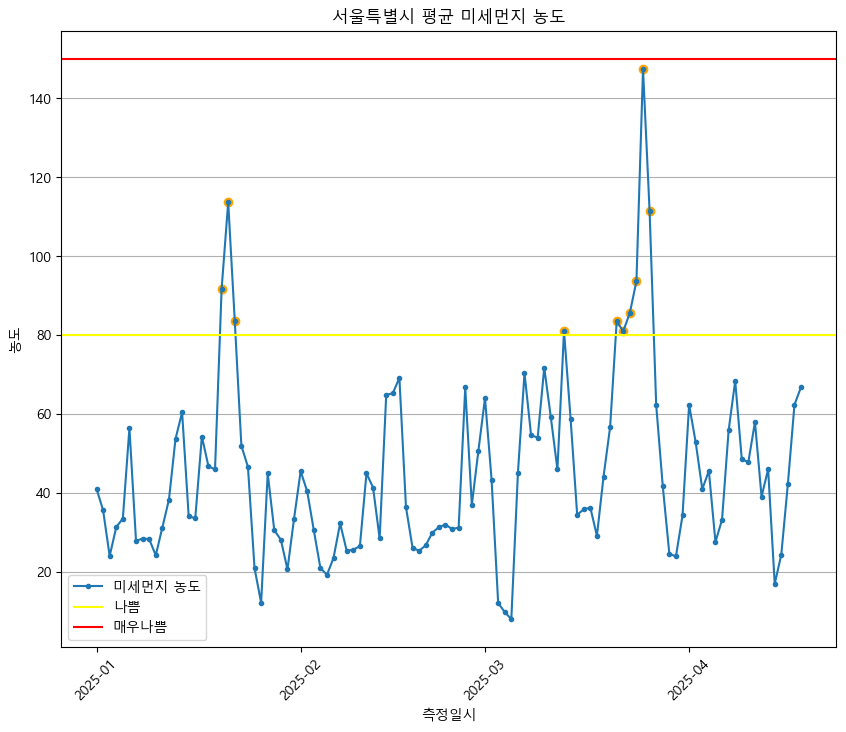

In [17]:
plt.figure(figsize=(10, 8))

x = data['측정일시']
y = data['미세먼지(㎍/㎥)']

plt.plot(x, y, label = '미세먼지 농도', marker = '.')

plt.axhline(y=80, color='yellow', label = '나쁨')
plt.axhline(y=150, color='r', label = '매우나쁨')
 
mask = (y > 80)
plt.scatter(x[mask], y[mask], color = 'orange', marker = 'o')

plt.grid(True, axis = 'y')

plt.xlabel('측정일시')
plt.ylabel('농도')
plt.title('서울특별시 평균 미세먼지 농도')
plt.legend()

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.show()

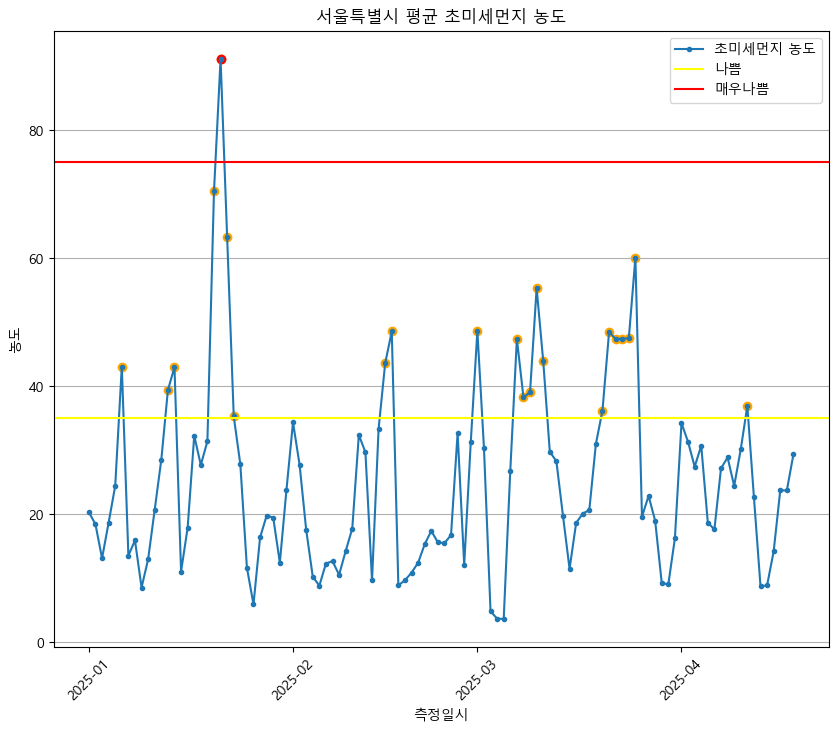

In [18]:
plt.figure(figsize=(10, 8))

x = data['측정일시']
y = data['초미세먼지(㎍/㎥)']

plt.plot(x, y, label = '초미세먼지 농도', marker = '.')

plt.axhline(y=35, color='yellow', label = '나쁨')
plt.axhline(y=75, color='r', label = '매우나쁨')
 
mask = (y > 35)
plt.scatter(x[mask], y[mask], color = 'orange', marker = 'o')

mask = (y > 75)
plt.scatter(x[mask], y[mask], color = 'red', marker = 'o')

plt.grid(True, axis = 'y')

plt.xlabel('측정일시')
plt.ylabel('농도')
plt.title('서울특별시 평균 초미세먼지 농도')
plt.legend()

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.show()

- 2025 1월부터 4월까지 보았을 때 서울시 대기오염은 초미세먼지의 경우가 더 심각하다는 것을 알 수 있다

# 측정소별 농도 확인

In [19]:
df_2025.head()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
0,2025-04-18,강남구,0.0164,0.0626,0.40,0.0029,68.0,32.0
1,2025-04-18,강남대로,0.0244,0.0405,0.48,0.0022,75.0,34.0
2,2025-04-18,강동구,0.0164,0.0671,0.62,0.0028,77.0,39.0
3,2025-04-18,강변북로,0.0417,0.0367,0.59,0.0028,81.0,28.0
4,2025-04-18,강북구,0.0102,0.0699,0.33,0.0023,56.0,31.0


In [20]:
df_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5400 entries, 0 to 5399
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          5400 non-null   datetime64[ns]
 1   측정소명          5400 non-null   object        
 2   이산화질소농도(ppm)  5396 non-null   float64       
 3   오존농도(ppm)     5396 non-null   float64       
 4   일산화탄소농도(ppm)  5396 non-null   float64       
 5   아황산가스(ppm)    5396 non-null   float64       
 6   미세먼지(㎍/㎥)     5397 non-null   float64       
 7   초미세먼지(㎍/㎥)    5397 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 379.7+ KB


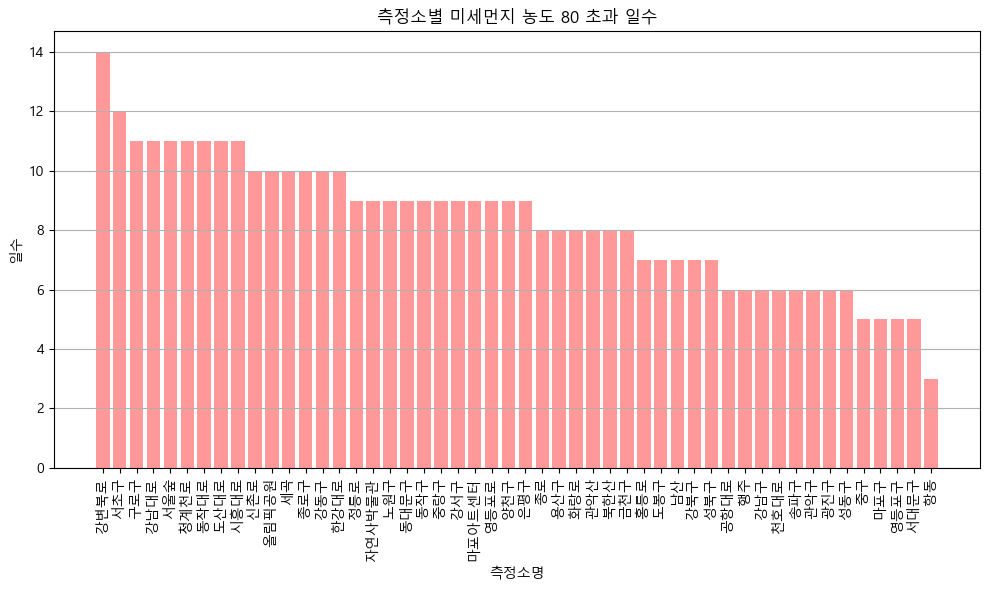

In [21]:
days = df_2025[df_2025["미세먼지(㎍/㎥)"]>80]['측정소명'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(days.index, days.values, color = 'red', alpha = 0.4 ,width=0.8)
plt.grid(True, axis='y')

plt.xlabel('측정소명')
plt.ylabel('일수')
plt.title('측정소별 미세먼지 농도 80 초과 일수')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

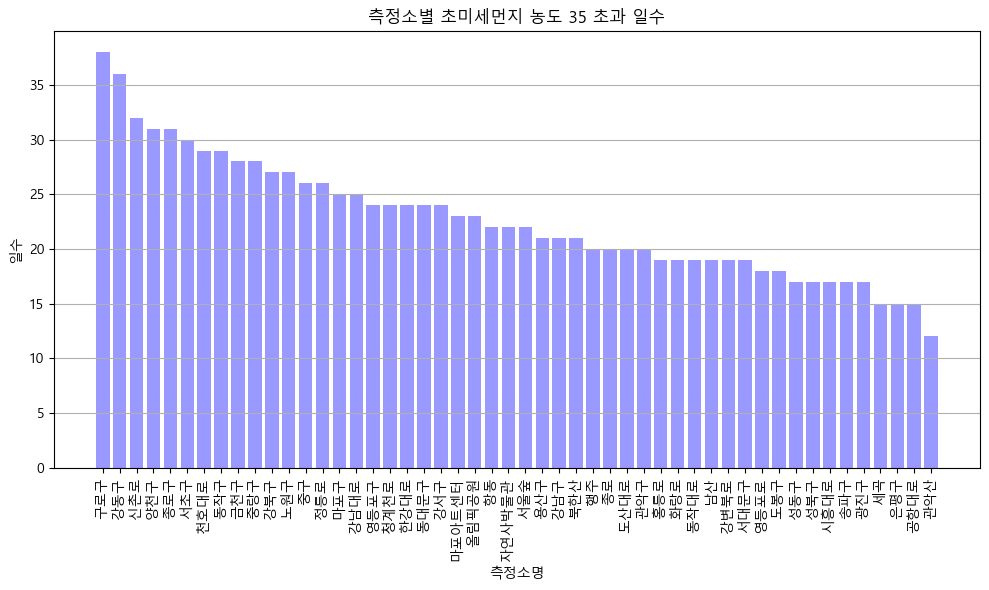

In [22]:
days = df_2025[df_2025["초미세먼지(㎍/㎥)"]>35]['측정소명'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(days.index, days.values, color = 'blue', alpha = 0.4 ,width=0.8)
plt.grid(True, axis='y')

plt.xlabel('측정소명')
plt.ylabel('일수')
plt.title('측정소별 초미세먼지 농도 35 초과 일수')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# 크게 지역구별로 초과 일수 확인

#### 지역별로 미세먼지 농도의 차이가 있다면, 그 이유를 추론해보자

In [23]:
big = df_2025[df_2025["측정소명"].str.endswith('구')]
big.head()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
0,2025-04-18,강남구,0.0164,0.0626,0.40,0.0029,68.0,32.0
2,2025-04-18,강동구,0.0164,0.0671,0.62,0.0028,77.0,39.0
4,2025-04-18,강북구,0.0102,0.0699,0.33,0.0023,56.0,31.0
5,2025-04-18,강서구,0.0176,0.0581,0.34,0.0031,63.0,25.0
7,2025-04-18,관악구,0.0155,0.0635,0.38,0.0031,68.0,29.0


In [24]:
big.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2700 entries, 0 to 5392
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          2700 non-null   datetime64[ns]
 1   측정소명          2700 non-null   object        
 2   이산화질소농도(ppm)  2697 non-null   float64       
 3   오존농도(ppm)     2697 non-null   float64       
 4   일산화탄소농도(ppm)  2697 non-null   float64       
 5   아황산가스(ppm)    2697 non-null   float64       
 6   미세먼지(㎍/㎥)     2697 non-null   float64       
 7   초미세먼지(㎍/㎥)    2697 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 189.8+ KB


In [25]:
big["측정소명"].unique()

array(['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구',
       '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구',
       '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구'], dtype=object)

In [26]:
count = big[big["미세먼지(㎍/㎥)"] > 80].groupby('측정소명').size()
count = count.sort_values()

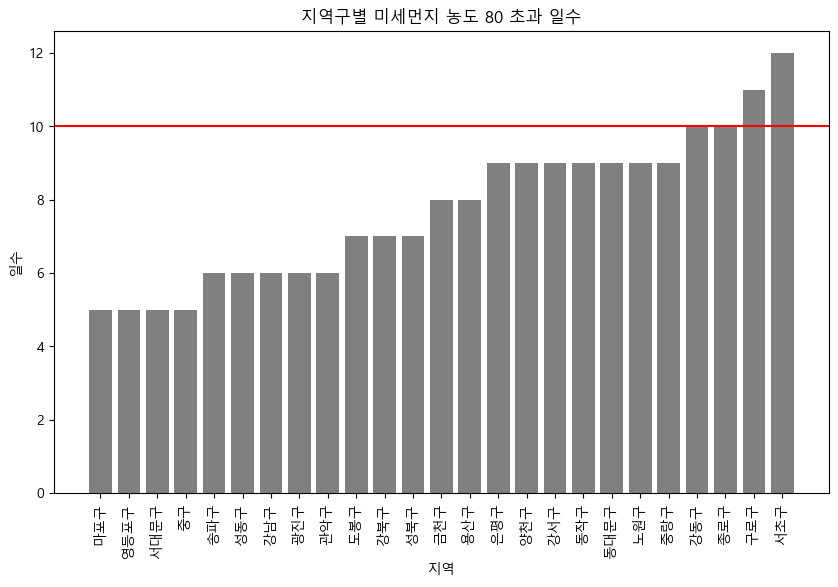

In [27]:
plt.figure(figsize=(10, 6))

plt.bar(count.index, count.values, color = 'grey')

plt.xlabel("지역")
plt.ylabel("일수")

plt.axhline(y=10, color='red')
plt.title("지역구별 미세먼지 농도 80 초과 일수")

plt.xticks(rotation=90)
plt.show()

- 미세먼지 농도가 서초구, 구로구, 종로구, 강동구는 10일 이상이 나쁨

In [44]:
count = big[big["초미세먼지(㎍/㎥)"] > 35].groupby('측정소명').size()
count = count.sort_values()

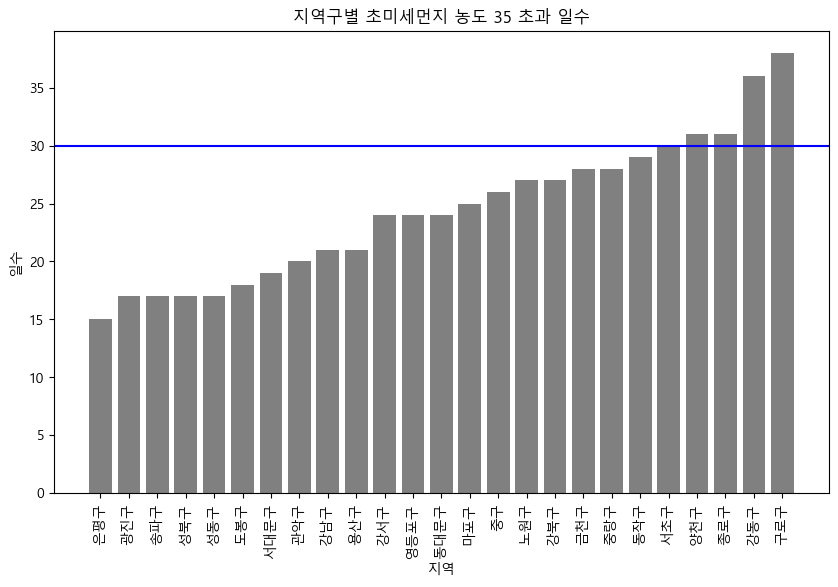

In [45]:
plt.figure(figsize=(10, 6))
plt.bar(count.index, count.values, color = 'grey')
plt.axhline(y=30, color='blue')

plt.xlabel("지역")
plt.ylabel("일수")
plt.title("지역구별 초미세먼지 농도 35 초과 일수")

plt.xticks(rotation=90)
plt.show()

- 초미세먼지 농도가 서초구, 양천구, 종로구, 강동구, 구로구는 30일 이상이 나쁨

#### 공통적으로 서초구, 종로구, 강동구, 구로구에서 유독 (초)미세먼지 농도가 나쁜 날이 많은 이유가 무엇일까

### 서초구
   - 강남대로, 남부순환로 등 대형 도로 교통량 많음
   - 남쪽이 산지(우면산 등)로 둘러싸여 있어 공기 흐름이 정체될 수 있음
    
### 종로구
   - 행정, 상업 중심지로 유동 인구와 차량 이동량이 매우 많음
   - 북쪽에 북한산이 위치하여 공기 흐름에 제약
       - 실제로 2017년 12월 국립공원관리공단에서 조사한 바에 따르면, 북한산으로 인해 종로5가와 불광동이 피해를 보고 있음

### 강동구
   - 한강 북쪽 산업지역, 하남시 개발과도 인접
   - 산지(고덕산, 일자산)로 둘러싸여 공기 흐름에 제약
    
### 구로구
   - 경인로, 남부순환로, 철도 인근 → 차량 및 물류 이동량 많음
   - 서울 서남부 산업단지 밀집 지역 (구로디지털단지)

## 대로별 교통량 확인

In [46]:
CURRENT_DIR = os.getcwd()
file_path = os.path.join(CURRENT_DIR, "Data", "간선도로+지점별+교통량_20250424194045.csv") 

print("현재 작업 디렉토리:", CURRENT_DIR)

if os.path.exists(file_path):
    df = pd.read_csv(file_path, encoding='utf-8')
else:
    print(f"🚨 파일을 찾을 수 없습니다! 경로를 확인하세요: {file_path}")
    raise FileNotFoundError(f"파일이 없습니다: {file_path}")

현재 작업 디렉토리: C:\Users\82102\OneDrive\바탕 화면\ai_project\프로젝트


In [47]:
df.head()

,간선도로 지점별(1),2023,2024
0,진흥로(구기터널),41213,39983
1,평창문화로(북악터널),41115,...
2,동호로(금호터널),61995,63601
3,서빙고로(한남역),84799,83438
4,천호대로(군자교),79570,80507


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   간선도로 지점별(1)  46 non-null     object
 1   2023         46 non-null     int64 
 2   2024         46 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.2+ KB


In [53]:
df["2024"] = pd.to_numeric(df["2024"], errors="coerce")

In [54]:
df.sort_values(by="2024", ascending=False)

,간선도로 지점별(1),2023,2024
11,동부간선도로(월계1교),123690,120627.0
18,남부순환로(신월IC),109544,109329.0
45,서부간선도로(오목교),104339,108073.0
38,남부순환로(수서IC),103973,102087.0
32,남부순환로(낙성대역),89886,85781.0
27,경인로(서울교),91117,84953.0
3,서빙고로(한남역),84799,83438.0
33,남부순환로(예술의전당),82012,81959.0
28,여의대방로(여의교),82005,81455.0
4,천호대로(군자교),79570,80507.0


In [55]:
df.sort_values(by="2023", ascending=False)

,간선도로 지점별(1),2023,2024
11,동부간선도로(월계1교),123690,120627.0
18,남부순환로(신월IC),109544,109329.0
45,서부간선도로(오목교),104339,108073.0
38,남부순환로(수서IC),103973,102087.0
27,경인로(서울교),91117,84953.0
32,남부순환로(낙성대역),89886,85781.0
35,사평대로(고속터미널역),84911,NaN
3,서빙고로(한남역),84799,83438.0
30,동작대로(총신대입구역),82544,80282.0
33,남부순환로(예술의전당),82012,81959.0


- 남부순환로가 제일 교통량이 많은 것을 알 수 있음 (서초구)
- 경인로, 남부순환로의 영향으로 미세먼지 농도가 높지않을까 유추할 수 있음 (구로구)

# 계절별 미세먼지 농도 시각화

- 12 ~ 2 : 겨울
- 3 ~ 5 : 봄
- 6 ~ 8 : 여름
- 9 ~ 11 : 가을

In [56]:
CURRENT_DIR = os.getcwd()
file_path = os.path.join(CURRENT_DIR, "Data", "일별평균대기오염도_2023.csv") 

print("현재 작업 디렉토리:", CURRENT_DIR)

if os.path.exists(file_path):
    df = pd.read_csv(file_path, encoding='cp949')
else:
    print(f"🚨 파일을 찾을 수 없습니다! 경로를 확인하세요: {file_path}")
    raise FileNotFoundError(f"파일이 없습니다: {file_path}")

현재 작업 디렉토리: C:\Users\82102\OneDrive\바탕 화면\ai_project\프로젝트


In [57]:
df.head()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
0,20230101,강남구,0.024,0.024,0.6,0.004,52.0,36.0
1,20230101,강동구,0.027,0.017,0.7,0.003,56.0,43.0
2,20230101,강북구,NaN,0.026,0.7,0.004,51.0,34.0
3,20230101,강서구,0.021,0.025,0.6,0.004,62.0,38.0
4,20230101,관악구,0.025,0.020,0.6,0.003,54.0,35.0


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   측정일시          18250 non-null  int64  
 1   측정소명          18250 non-null  object 
 2   이산화질소농도(ppm)  18159 non-null  float64
 3   오존농도(ppm)     18157 non-null  float64
 4   일산화탄소농도(ppm)  17766 non-null  float64
 5   아황산가스농도(ppm)  18029 non-null  float64
 6   미세먼지농도(㎍/㎥)   18137 non-null  float64
 7   초미세먼지농도(㎍/㎥)  18132 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 1.1+ MB


In [59]:
df['측정일시'] = pd.to_datetime(df['측정일시'], format='%Y%m%d')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          18250 non-null  datetime64[ns]
 1   측정소명          18250 non-null  object        
 2   이산화질소농도(ppm)  18159 non-null  float64       
 3   오존농도(ppm)     18157 non-null  float64       
 4   일산화탄소농도(ppm)  17766 non-null  float64       
 5   아황산가스농도(ppm)  18029 non-null  float64       
 6   미세먼지농도(㎍/㎥)   18137 non-null  float64       
 7   초미세먼지농도(㎍/㎥)  18132 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 1.1+ MB


In [61]:
seoul_data = df.groupby('측정일시')[["미세먼지농도(㎍/㎥)", "초미세먼지농도(㎍/㎥)"]].mean()
print(seoul_data)

            미세먼지농도(㎍/㎥)  초미세먼지농도(㎍/㎥)
측정일시                                 
2023-01-01    51.795918         36.52
2023-01-02    24.820000         11.02
2023-01-03    29.780000         16.18
2023-01-04    35.420000         22.58
2023-01-05    49.320000         35.28
...                 ...           ...
2023-12-27    75.620000         56.66
2023-12-28    52.180000         40.28
2023-12-29    42.400000         32.08
2023-12-30    39.180000         30.90
2023-12-31    22.500000         17.40

[365 rows x 2 columns]


In [62]:
seoul_data.to_csv('서울특별시_일별_평균2024.csv', index=True, encoding='cp949')
seoul_data

,미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
측정일시,,
2023-01-01,51.795918,36.52
2023-01-02,24.820000,11.02
2023-01-03,29.780000,16.18
2023-01-04,35.420000,22.58
2023-01-05,49.320000,35.28
...,...,...
2023-12-27,75.620000,56.66
2023-12-28,52.180000,40.28
2023-12-29,42.400000,32.08


In [64]:
df = pd.read_csv("서울특별시_일별_평균2024.csv", encoding='cp949')
df["측정일시"] = pd.to_datetime(df['측정일시'])

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          365 non-null    datetime64[ns]
 1   미세먼지농도(㎍/㎥)   365 non-null    float64       
 2   초미세먼지농도(㎍/㎥)  365 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 8.7 KB


# 2023 기준 미세먼지 농도 일수 시각화

In [68]:
df.tail()

,측정일시,미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
360,2023-12-27,75.62,56.66
361,2023-12-28,52.18,40.28
362,2023-12-29,42.40,32.08
363,2023-12-30,39.18,30.90
364,2023-12-31,22.50,17.40


### 월별 농도 시각화

In [69]:
# 계절 정의
season_labels = {
    12: "겨울", 1: "겨울", 2: "겨울",
    3: "봄", 4: "봄", 5: "봄",
    6: "여름", 7: "여름", 8: "여름",
    9: "가을", 10: "가을", 11: "가을"
}

In [76]:
pm10_data = df[df['미세먼지농도(㎍/㎥)']>80]

bins = [0, 2, 5, 8, 11, 13]
labels = ['겨울', '봄', '여름', '가을', '겨울']

pm10_data['계절'] = pd.cut(pm10_data['측정일시'].dt.month, bins=bins, labels=labels, ordered=False)

season_count = pm10_data['계절'].value_counts()
season_count = season_count[season_count>0]

C:\Users\82102\AppData\Local\Temp\ipykernel_3920\3169129748.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pm10_data['계절'] = pd.cut(pm10_data['측정일시'].dt.month, bins=bins, labels=labels, ordered=False)


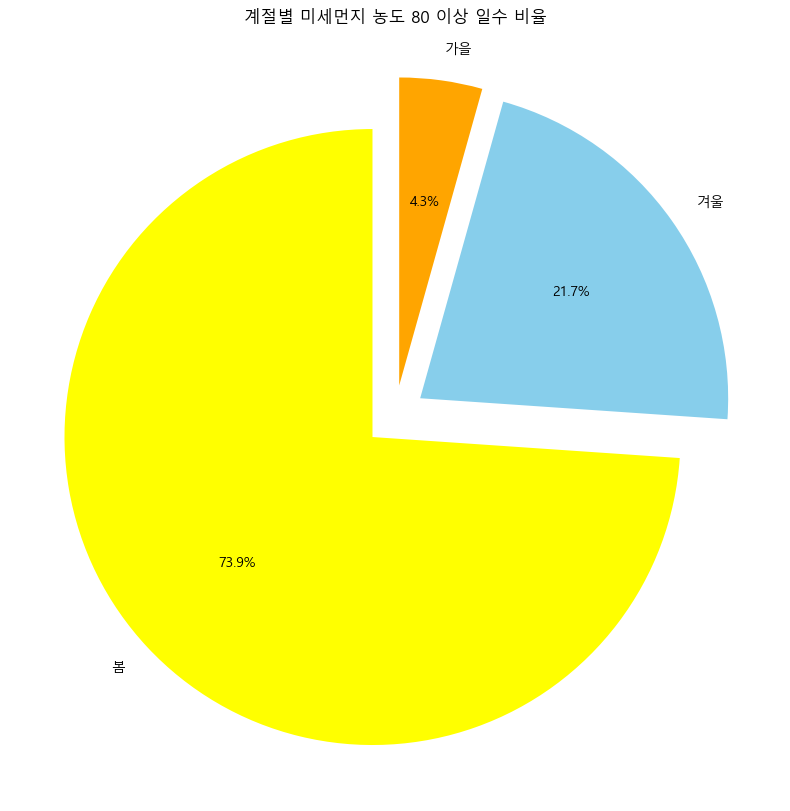

In [81]:
plt.figure(figsize=(10, 10))
colors = ['yellow','skyblue', 'orange']
explode = (0.1, 0.1, 0.1)
plt.pie(season_count, labels=season_count.index, explode=explode, autopct='%1.1f%%', colors = colors, startangle=90)
plt.title("계절별 미세먼지 농도 80 이상 일수 비율")
plt.show()

- 봄이 미세먼지 농도가 나쁜 일수가 압도적으로 많음
- 여름의 경우, 80을 넘는 날이 없었음

### 계절별 초미세먼지 농도 35 초과 일수 시각화

In [83]:
pm25_data = df[df['초미세먼지농도(㎍/㎥)']>35]

bins = [0, 2, 5, 8, 11, 13]
labels = ['겨울', '봄', '여름', '가을', '겨울']

pm25_data['계절'] = pd.cut(pm25_data['측정일시'].dt.month, bins=bins, labels=labels, ordered=False)

season_count = pm25_data['계절'].value_counts()
season_count = season_count[season_count>0]

C:\Users\82102\AppData\Local\Temp\ipykernel_3920\1338696920.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pm25_data['계절'] = pd.cut(pm25_data['측정일시'].dt.month, bins=bins, labels=labels, ordered=False)


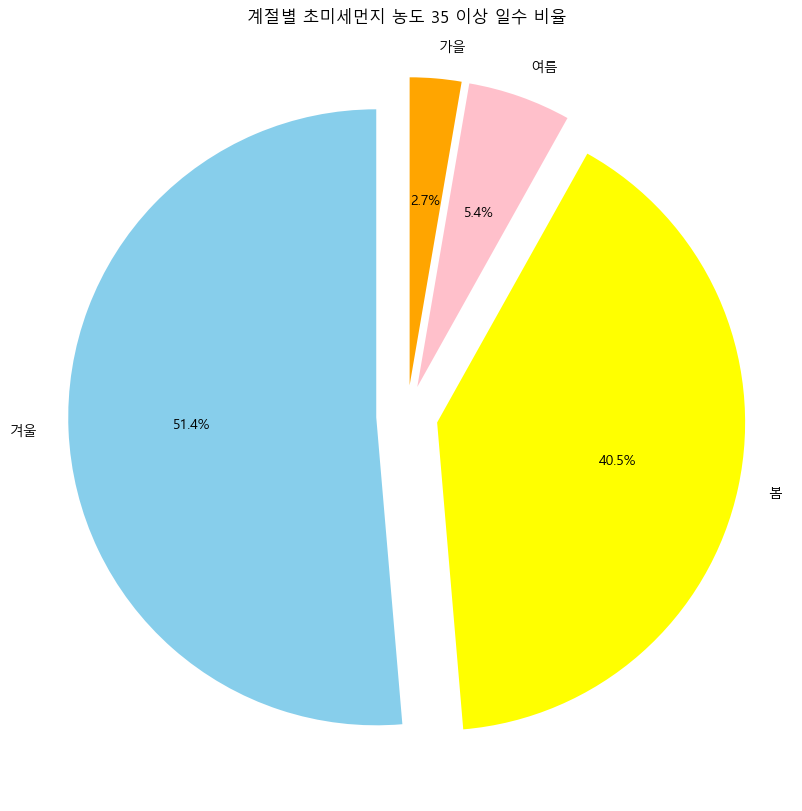

In [88]:
plt.figure(figsize=(10, 10))
colors = ['skyblue', 'yellow','pink','orange']
explode = (0.1, 0.1, 0.1, 0.1)
plt.pie(season_count, labels=season_count.index, autopct='%1.1f%%',explode=explode,  colors = colors, startangle=90)
plt.title("계절별 초미세먼지 농도 35 이상 일수 비율")
plt.show()

- 초미세먼지의 경우 겨울, 봄 둘다 높은 일수가 많지만 겨울이 조금 더 앞선 걸 확인할 수 있음
- 앞선 미세먼지 농도와 달리 여름도 나쁨지수에 해당하는 날이 있었음

# 2-3. 미세먼지 저감 정책 시기와 비교

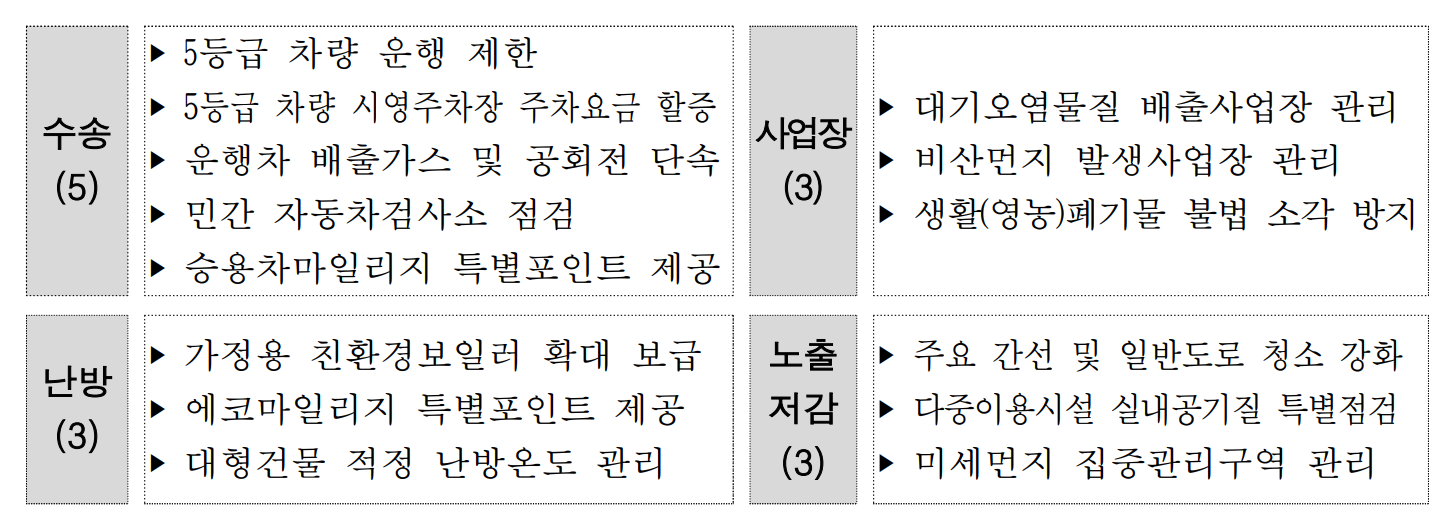

### 2022.12 ~ 2023.3 4차 계절관리제 시행

- 유성님 파일 확인시 2022년 12월에 미세먼지와 초미세먼지 농도가 앞선 2021, 2020, 2019... 년도보다 낮은 게 확인됨

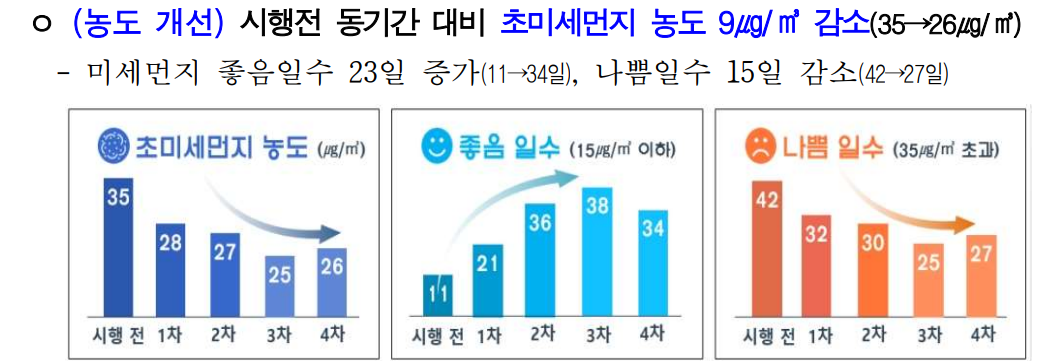

- 찾아보니 실제로 효과가 있었다고 함 

### 2023.12 ~ 2024.3 5차 계절관리제 시행

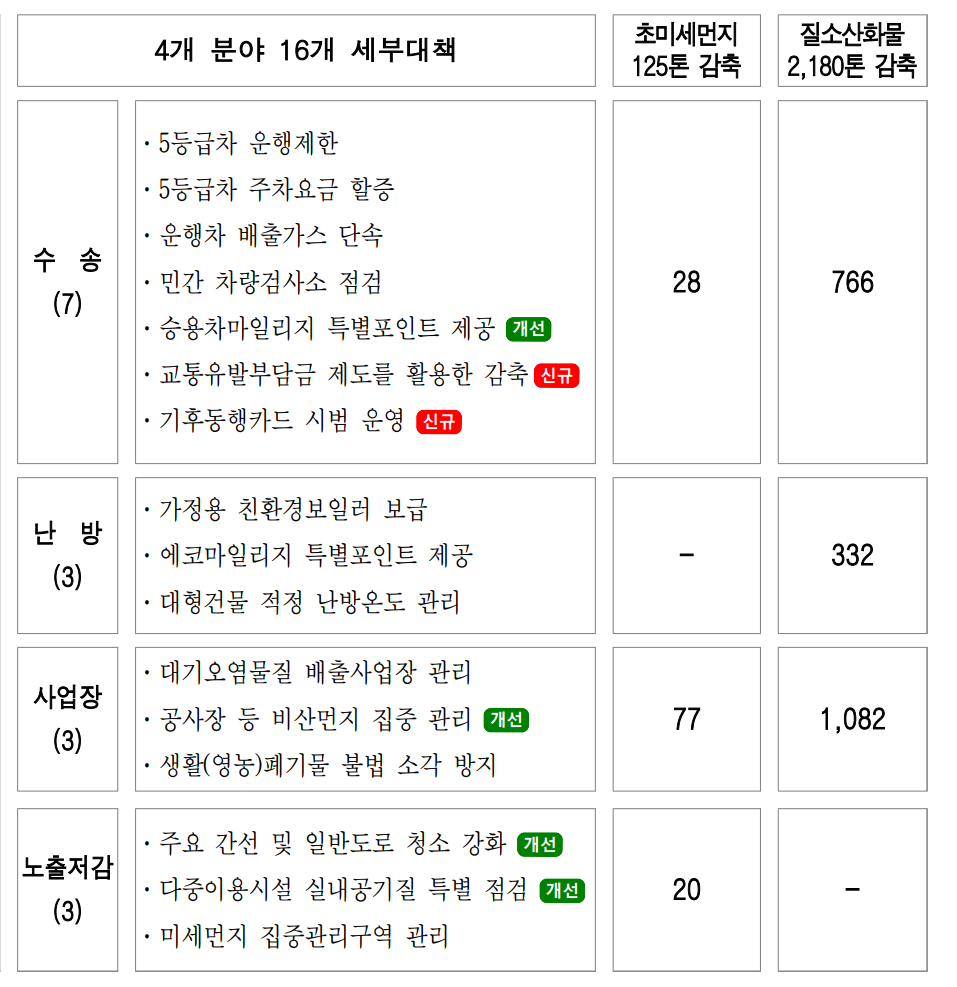

- 5차 계절관리제 정책

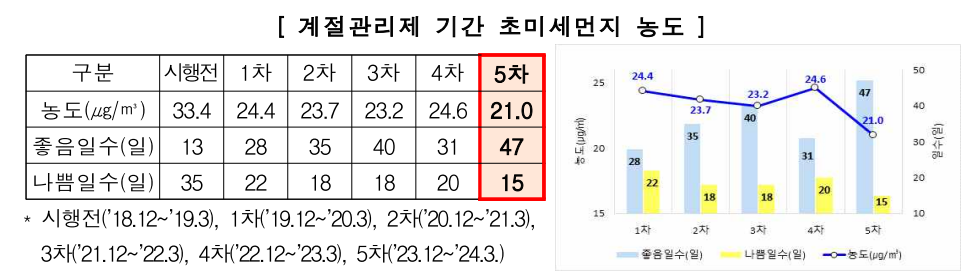

- 5차에서 최저를 기록하며 효과적인 정책임을 입증하였다

## 실제 평균으로 비교

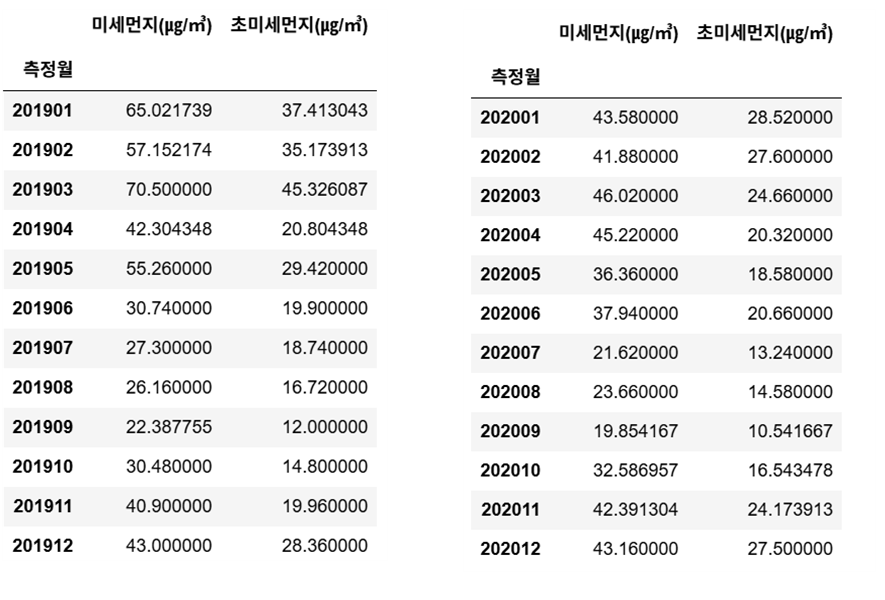

- 19년도 12월 미세먼지 초미세먼지는 각각 43, 28 정도
- 20년도 역시 19년도와 거의 동일함

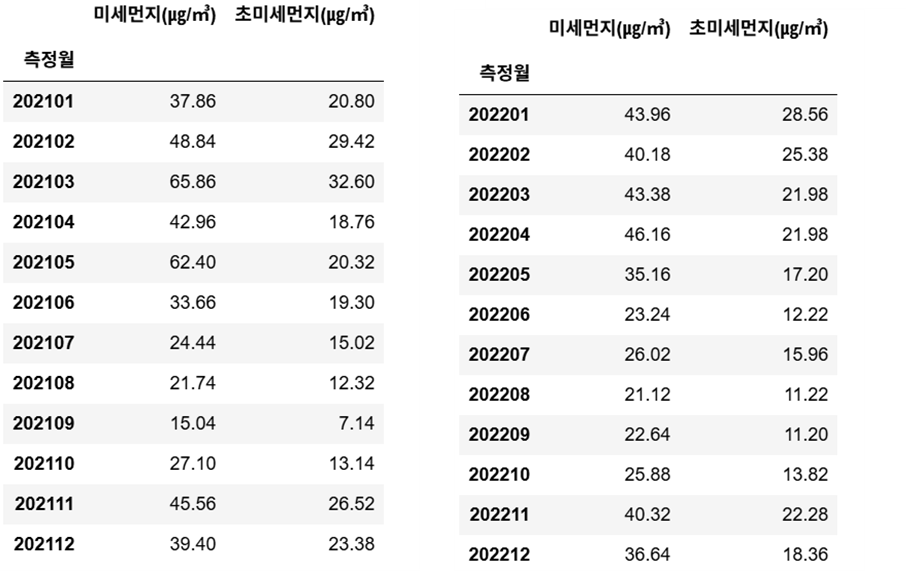

- 3차 계절관리제를 시행한 21.12은 이전보다 낮은 39, 23을 기록함
- 4차 계절관리제를 시행한 22.12의 경우 21년보다 개선되어 36, 18을 기록함

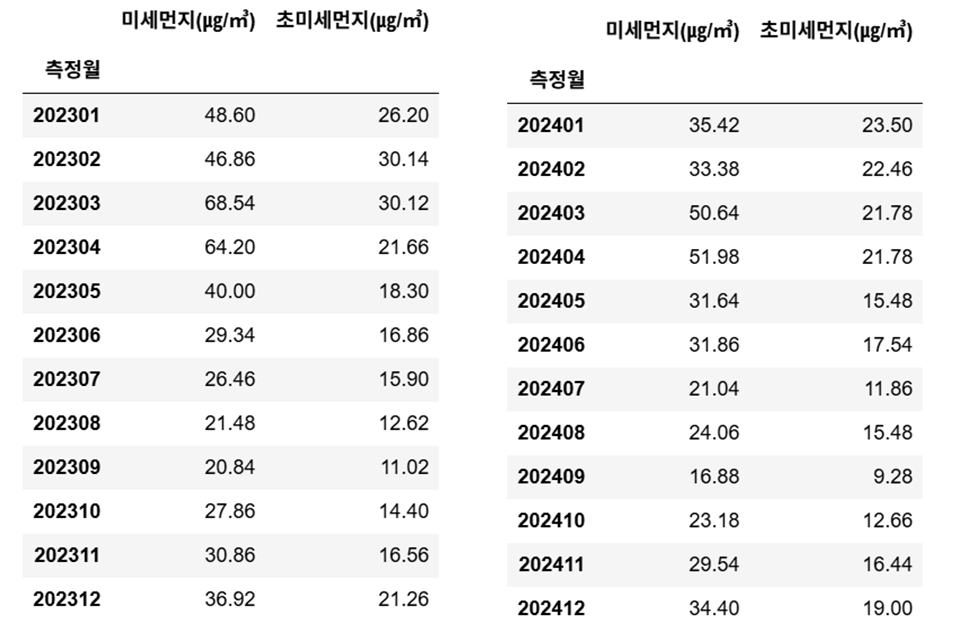

- 23년 3월에 갑자기 미세먼지와 초미세먼지 농도가 68, 30으로 상승 
- 5차 계절관리제를 시행한 24년도에는 23년 보다 개선된 것을 확인할 수 있음

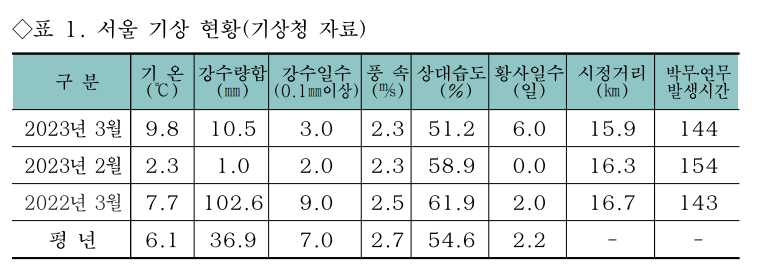

- 23년 3월 기준 22년도보다 평균 기온이 2도 올라갔고, 강수량은 줄어들었으며, 황사일수는 증가함. 습도는 낮아짐
- 풍속이 감소해 대기 정체가 일어났을 가능성도 있음 (황사는 미세먼지의 주요요인으로 꼽힘)
- 기상의 영향으로 높아진 것이 아닐까 유추할 수 있음